# Make Figure of drift during spin-up


Begin a session in Expanse with: galyleo launch --account ciw112 --partition large-shared --cpus 64 --memory 500 --time-limit 12:00:00 --conda-env df-parallel --conda-yml "${HOME}/df-parallel/samw_analysis_env.yml" --mamba

## imports

In [1]:

import sys
import os
import numpy as np
import pandas as pd
import xarray as xr
import dask as da
from dask.diagnostics import ProgressBar

# plotting packages
#import seaborn as sb
#sb.set(style='ticks')
import h5py
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from matplotlib import colors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# regridding
import xesmf as xe

# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("dask version =", da.__version__)
#print("seaborn version =", sb.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


import matplotlib.path as mpath
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)


wrkdir = "/expanse/lustre/projects/ciw112/pbuchanan/JRA55"
os.chdir(wrkdir)


python version = 3.10.
numpy version = 1.26.4
pandas version = 2.2.3
xarray version = 2024.3.0
dask version = 2023.3.0
matplotlib version = 3.7.1
cmocean version = v3.0.3
cartopy version = 0.24.0
xesmf version = 0.8.7


## load model output

In [7]:

mod = xr.open_dataset('JRA55_pic_1y_bioscaler_1638-2022.nc').squeeze()
year = np.arange(1638.5,2022.51,1)
mod = mod.assign_coords(time_counter=year)
mod = mod.rename({'time_counter':'year'})

mod


<xarray.Dataset> Size: 45kB
Dimensions:               (nvertex: 4, year: 385, axis_nbounds: 2)
Coordinates:
    nav_lat               float32 4B ...
    nav_lon               float32 4B ...
    time_centered         (year) object 3kB ...
  * year                  (year) float64 3kB 1.638e+03 1.64e+03 ... 2.022e+03
Dimensions without coordinates: nvertex, axis_nbounds
Data variables: (12/22)
    area                  float32 4B ...
    bounds_nav_lat        (nvertex) float32 16B ...
    bounds_nav_lon        (nvertex) float32 16B ...
    palktot               (year) float32 2kB ...
    pd13dictot            (year) float32 2kB ...
    pd15no3tot            (year) float32 2kB ...
    ...                    ...
    time_centered_bounds  (year, axis_nbounds) object 6kB ...
    time_counter_bounds   (year, axis_nbounds) object 6kB ...
    tintpp                (year) float32 2kB ...
    tnfix                 (year) float32 2kB ...
    tnh4ox                (year) float32 2kB ...
    tno2ox                (year) float32 2kB ...
Attributes: (12/23)
    name:                      ORCA2_1y_00010101_00011231_bioscalar
    description:               pisces sms variables
    title:                     pisces sms variables
    Conventions:               CF-1.6
    timeStamp:                 2023-Mar-21 03:31:55 GMT
    uuid:                      e37cff6c-fd7f-49c4-993d-1ff0b671865b
    ...                        ...
    DOMAIN_halo_size_start:    [0 0]
    DOMAIN_halo_size_end:      [0 0]
    DOMAIN_type:               box
    history:                   Mon Aug 28 00:16:58 2023: ncrcat -O JRA55_pic_...
    NCO:                       netCDF Operators version 4.7.5 (Homepage = htt...
    nco_openmp_thread_number:  1

## Plot the drift

Text(0.05, 1.0, 'd')

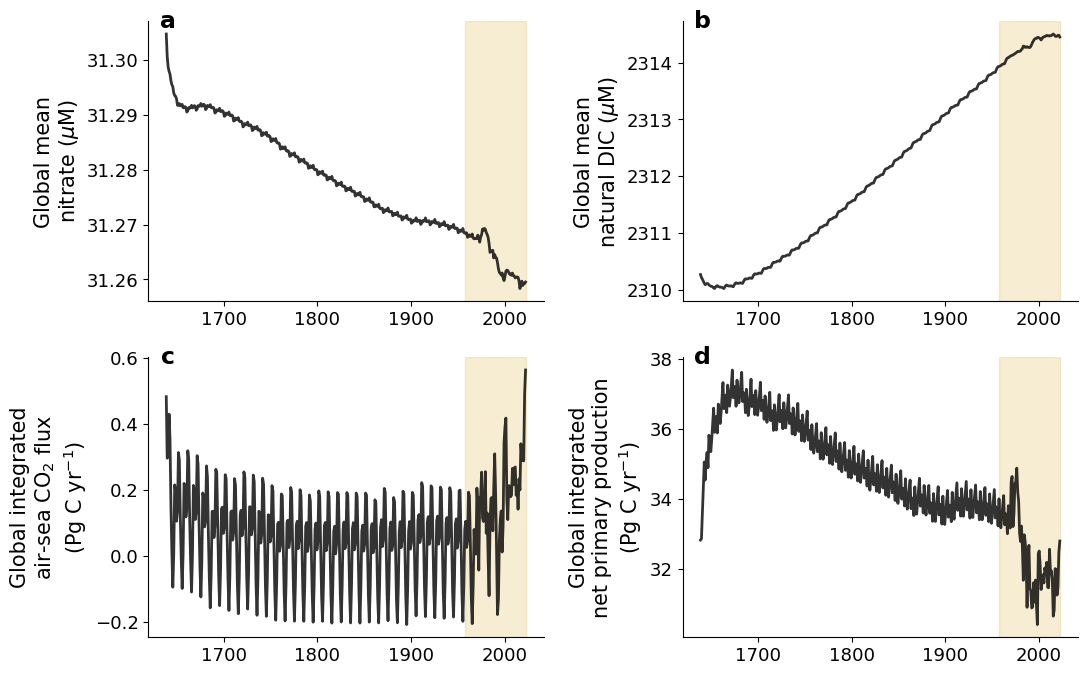

In [22]:

fslab = 15
fstic = 13
alf = 0.8
col = 'k'
lwid = 2
lsty = '-'

fig = plt.figure(figsize=(12,8))
gs = GridSpec(2,2)

ax1 = plt.subplot(gs[0,0])
ax2 = plt.subplot(gs[0,1])
ax3 = plt.subplot(gs[1,0])
ax4 = plt.subplot(gs[1,1])

ax1.tick_params(labelsize=fstic)
ax2.tick_params(labelsize=fstic)
ax3.tick_params(labelsize=fstic)
ax4.tick_params(labelsize=fstic)

ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top', 'right']].set_visible(False)
ax3.spines[['top', 'right']].set_visible(False)
ax4.spines[['top', 'right']].set_visible(False)

ax1.plot(mod.coords['year'], mod['pno3tot'], color=col, alpha=alf, linewidth=lwid, linestyle=lsty)
ax2.plot(mod.coords['year'], mod['pdictot'], color=col, alpha=alf, linewidth=lwid, linestyle=lsty)
ax3.plot(mod.coords['year'], mod['tcflx'], color=col, alpha=alf, linewidth=lwid, linestyle=lsty)
ax4.plot(mod.coords['year'], mod['tintpp'], color=col, alpha=alf, linewidth=lwid, linestyle=lsty)

ax1.axvspan(1958,2023, color='goldenrod', alpha=0.2)
ax2.axvspan(1958,2023, color='goldenrod', alpha=0.2)
ax3.axvspan(1958,2023, color='goldenrod', alpha=0.2)
ax4.axvspan(1958,2023, color='goldenrod', alpha=0.2)

ax1.set_ylabel("Global mean\nnitrate ($\mu$M)", fontsize=fslab)
ax2.set_ylabel("Global mean\nnatural DIC ($\mu$M)", fontsize=fslab)
ax3.set_ylabel("Global integrated\nair-sea CO$_2$ flux\n(Pg C yr$^{-1}$)", fontsize=fslab)
ax4.set_ylabel("Global integrated\nnet primary production\n(Pg C yr$^{-1}$)", fontsize=fslab)

plt.subplots_adjust(wspace=0.35)

xx=0.05; yy=1.00
plt.text(xx,yy, "a", fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy, "b", fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy, "c", fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy, "d", fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)


In [24]:

fig.savefig('/home/pbuchanan/analysis_samw/fig-drift.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-drift.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-drift_trans.png', dpi=300, bbox_inches='tight', transparent=True)


<xarray.DataArray 'lon' ()> Size: 4B
array(22.000566, dtype=float32)
Coordinates:
    lat      float32 4B -78.19
    lon      float32 4B 22.0


/scratch/pbuchanan/job_37456731/ipykernel_660250/1821932123.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(sind_mld_anom.coords['lon'], sind_mld_anom.coords['lat'], sind_mld_anom.sel(year=2015.5, month=8))


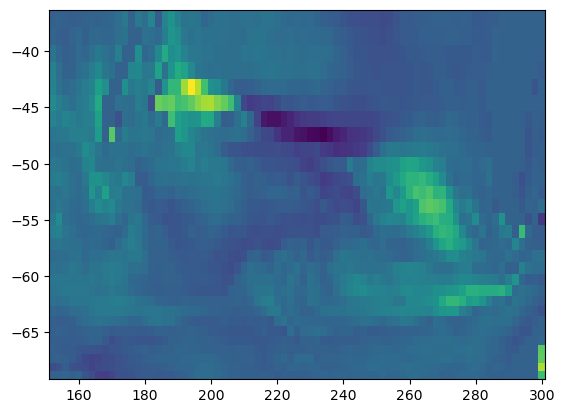

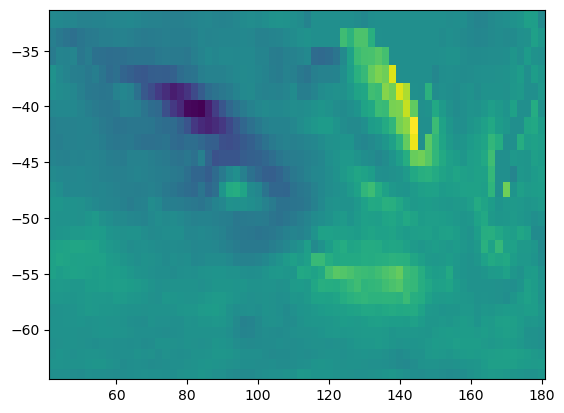

In [94]:
mld_anom = mld.sel(year=slice(2005,2023)) - mld.sel(year=slice(2005,2023)).mean(dim='year')

mld_anom = mld_anom.roll(x=30, roll_coords=True)

lon = mld_anom.coords['lon']
lat = mld_anom.coords['lat']
lon_positive = lon.where(lon >= 0.0, lon + 360.0)
print(lon_positive[0,0])

mld_anom = mld_anom.assign_coords({"lon":lon_positive})

spac_mld_anom = mld_anom.where((mld_anom.coords['lon'] > plon1) & (mld_anom.coords['lon'] < plon2), other=np.nan)
spac_mld_anom = spac_mld_anom.where((spac_mld_anom.coords['lat'] > plat1) & (spac_mld_anom.coords['lat'] < plat2), other=np.nan)
spac_area = area.where((mld_anom.coords['lon'] > plon1) & (mld_anom.coords['lon'] < plon2), other=np.nan)
spac_area = spac_area.where((spac_mld_anom.coords['lat'] > plat1) & (spac_mld_anom.coords['lat'] < plat2), other=np.nan)

sind_mld_anom = mld_anom.where((mld_anom.coords['lon'] > ilon1) & (mld_anom.coords['lon'] < ilon2), other=np.nan)
sind_mld_anom = sind_mld_anom.where((sind_mld_anom.coords['lat'] > ilat1) & (sind_mld_anom.coords['lat'] < ilat2), other=np.nan)
sind_area = area.where((mld_anom.coords['lon'] > ilon1) & (mld_anom.coords['lon'] < ilon2), other=np.nan)
sind_area = sind_area.where((sind_mld_anom.coords['lat'] > ilat1) & (sind_mld_anom.coords['lat'] < ilat2), other=np.nan)

spac_mld_anom = spac_mld_anom.where(~np.isnan(spac_mld_anom), drop=True)
sind_mld_anom = sind_mld_anom.where(~np.isnan(sind_mld_anom), drop=True)
spac_area = spac_area.where(~np.isnan(spac_area), drop=True)
sind_area = sind_area.where(~np.isnan(sind_area), drop=True)

plt.figure()
plt.pcolormesh(spac_mld_anom.coords['lon'], spac_mld_anom.coords['lat'], spac_mld_anom.sel(year=2015.5, month=8))
plt.figure()
plt.pcolormesh(sind_mld_anom.coords['lon'], sind_mld_anom.coords['lat'], sind_mld_anom.sel(year=2015.5, month=8))


In [95]:
from datetime import datetime, timedelta

start_date = datetime(2005, 1, 1)
end_date = datetime(2022, 12, 31)
time = pd.date_range(start=start_date, end=end_date, freq="MS") + pd.DateOffset(days=14)
time

# blend years and months into one time dimension
spac_mld_anom = spac_mld_anom.stack(time=("year", "month"))
sind_mld_anom = sind_mld_anom.stack(time=("year", "month"))
spac_mld_anom = spac_mld_anom.drop_vars(['year', 'month', 'time_centered'])
sind_mld_anom = sind_mld_anom.drop_vars(['year', 'month', 'time_centered'])
spac_mld_anom = spac_mld_anom.assign_coords(time=time)
sind_mld_anom = sind_mld_anom.assign_coords(time=time)


In [96]:
### Single Value Decomposition on Pacific data

weights = spac_area.mean(dim='year') / spac_area.mean(dim='year').sum()
W_pac = weights**0.5
X = spac_mld_anom * W_pac
Xpac = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xpac.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xpac.T * 0 + U
U_pac = U_.unstack('space') * W_pac**(-1)
U_pac = U_pac.rename({"time":"mode"})
U_pac = U_pac.assign_coords({"mode":np.arange(len(S))})

S_pac = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_pac = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xpac.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_pac = S_pac**2.0
VE_pac = S2_pac / S2_pac.sum()

print(np.shape(Xpac.T))
print(np.shape(U_pac))
print(np.shape(S_pac))
print(np.shape(V_pac))
print(np.shape(VE_pac))


(2175, 216)
(216, 29, 75)
(216,)
(216, 216)
(216,)


In [97]:
### Single Value Decomposition on Indian data

weights = sind_area.mean(dim='year') / sind_area.mean(dim='year').sum()
W_ind = weights**0.5
X = sind_mld_anom * W_ind
Xind = X.stack(space=("y","x"))

U, S, V = np.linalg.svd(Xind.T.values, full_matrices=False)

### reconstruct the dimensions of the original data

U_ = Xind.T * 0 + U
U_ind = U_.unstack('space') * W_ind**(-1)
U_ind = U_ind.rename({"time":"mode"})
U_ind = U_ind.assign_coords({"mode":np.arange(len(S))})

S_ind = xr.DataArray(
    S,
    dims=["mode"],
    coords={"mode":np.arange(len(S))}
)

V_ind = xr.DataArray(
    V.T,
    dims=["time","mode"],
    coords={
        "time":Xind.coords['time'].values,
        "mode":np.arange(len(S))
    }
)

# variance explained
S2_ind = S_ind**2.0
VE_ind = S2_ind / S2_ind.sum()

print(np.shape(Xind.T))
print(np.shape(U_ind))
print(np.shape(S_ind))
print(np.shape(V_ind))
print(np.shape(VE_ind))


(1872, 216)
(216, 26, 72)
(216,)
(216, 216)
(216,)


In [98]:
### regrid the EOFs to a regular grid

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(plat1,plat2+0.5,0.5)),
        "lon": (["lon"], np.arange(plon1,plon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_pac, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_pac_reg = regridder(U_pac)

target_grid = xr.Dataset(
    {
        "lat": (["lat"], np.arange(ilat1,ilat2+0.5,0.5)),
        "lon": (["lon"], np.arange(ilon1,ilon2+0.5,0.5)),
    }
)

regridder = xe.Regridder(U_ind, target_grid, 'bilinear', ignore_degenerate=True, periodic=True)
U_ind_reg = regridder(U_ind)



Text(0.05, 1.05, 'j')

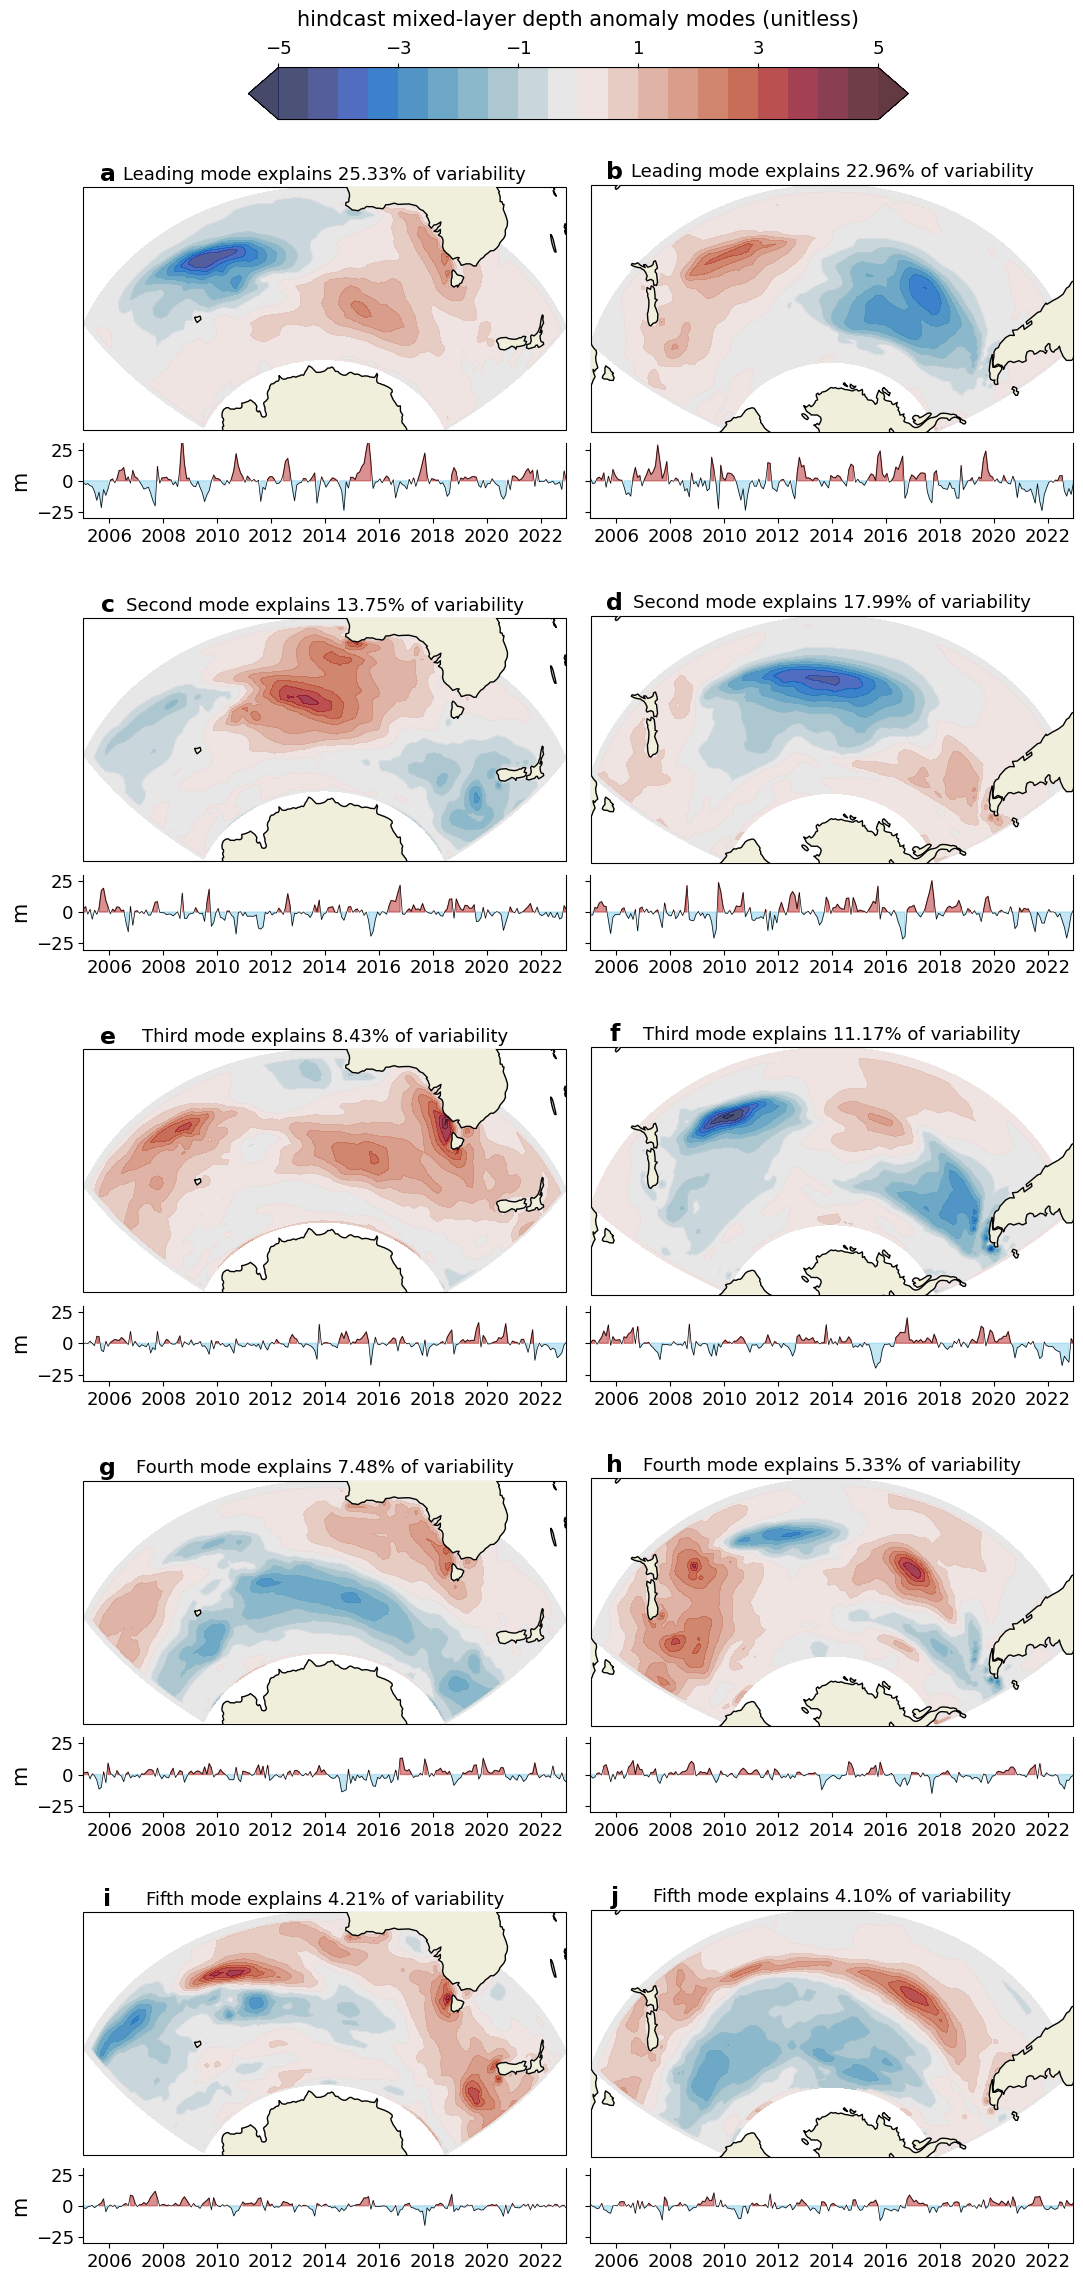

In [99]:
#%% Look at what the leading modes are in terms of spatial patterns

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=110)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']


levs = np.arange(-5,5.1,0.5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0
lwid = 0.5

fig = plt.figure(figsize=(11,26), facecolor='w')
gs = GridSpec(25,2)

ax1 = plt.subplot(gs[0:3,0], projection=sind_proj)
ax2 = plt.subplot(gs[0:3,1], projection=spac_proj)
ax1p = plt.subplot(gs[3,0])
ax2p = plt.subplot(gs[3,1])
ax3 = plt.subplot(gs[5:8,0], projection=sind_proj)
ax4 = plt.subplot(gs[5:8,1], projection=spac_proj)
ax3p = plt.subplot(gs[8,0])
ax4p = plt.subplot(gs[8,1])
ax5 = plt.subplot(gs[10:13,0], projection=sind_proj)
ax6 = plt.subplot(gs[10:13,1], projection=spac_proj)
ax5p = plt.subplot(gs[13,0])
ax6p = plt.subplot(gs[13,1])
ax7 = plt.subplot(gs[15:18,0], projection=sind_proj)
ax8 = plt.subplot(gs[15:18,1], projection=spac_proj)
ax7p = plt.subplot(gs[18,0])
ax8p = plt.subplot(gs[18,1])
ax9 = plt.subplot(gs[20:23,0], projection=sind_proj)
ax10 = plt.subplot(gs[20:23,1], projection=spac_proj)
ax9p = plt.subplot(gs[23,0])
ax10p = plt.subplot(gs[23,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)
ax9.add_feature(cfeature.LAND, zorder=3)
ax9.add_feature(cfeature.COASTLINE, zorder=3)
ax10.add_feature(cfeature.LAND, zorder=3)
ax10.add_feature(cfeature.COASTLINE, zorder=3)


p1 = ax1.contourf(indlons,indlats, U_ind_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode explains %.2f%% of variability'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=0) * V_ind.sel(mode=0))
tmp_pac = (S_pac.sel(mode=0) * V_pac.sel(mode=0))
ax1p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=lwid)
ax2p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=lwid)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax1p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax2p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax3p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=lwid)
ax4p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=lwid)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax3p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax4p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 2 
p5 = ax5.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p6 = ax6.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)+1e-2, transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Third mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax5p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=lwid)
ax6p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=lwid)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax5p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax6p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)

imodes = 3 
p7 = ax7.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p8 = ax8.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fourth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax7p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=lwid)
ax8p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=lwid)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax7p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax8p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)


imodes = 4 
p9 = ax9.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
p10 = ax10.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs, extend='both')
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_ind.sel(mode=imodes).values*100), transform=ax9.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Fifth mode explains %.2f%% of variability'%(VE_pac.sel(mode=imodes).values*100), transform=ax10.transAxes, va='center', ha='center', fontsize=fstic)

tmp_ind = (S_ind.sel(mode=imodes) * V_ind.sel(mode=imodes))
tmp_pac = (S_pac.sel(mode=imodes) * V_pac.sel(mode=imodes))
ax9p.plot(V_ind.coords['time'], tmp_ind, color='k', linewidth=lwid)
ax10p.plot(V_pac.coords['time'], tmp_pac, color='k', linewidth=lwid)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind > 0.0), color='firebrick', alpha=0.5)
ax9p.fill_between(V_ind.coords['time'], 0.0, tmp_ind.where(tmp_ind < 0.0), color='skyblue', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac > 0.0), color='firebrick', alpha=0.5)
ax10p.fill_between(V_pac.coords['time'], 0.0, tmp_pac.where(tmp_pac < 0.0), color='skyblue', alpha=0.5)

ax1p.spines['top'].set_visible(False)
ax2p.spines['top'].set_visible(False)
ax3p.spines['top'].set_visible(False)
ax4p.spines['top'].set_visible(False)
ax5p.spines['top'].set_visible(False)
ax6p.spines['top'].set_visible(False)
ax7p.spines['top'].set_visible(False)
ax8p.spines['top'].set_visible(False)
ax9p.spines['top'].set_visible(False)
ax10p.spines['top'].set_visible(False)

ax1p.tick_params(labelsize=fstic)
ax2p.tick_params(labelsize=fstic, labelleft=False)
ax3p.tick_params(labelsize=fstic)
ax4p.tick_params(labelsize=fstic,labelleft=False)
ax5p.tick_params(labelsize=fstic)
ax6p.tick_params(labelsize=fstic,labelleft=False)
ax7p.tick_params(labelsize=fstic)
ax8p.tick_params(labelsize=fstic,labelleft=False)
ax9p.tick_params(labelsize=fstic)
ax10p.tick_params(labelsize=fstic,labelleft=False)

ax1p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax2p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax3p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax4p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax5p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax6p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax7p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax8p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax9p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())
ax10p.set_xlim(V_ind.coords['time'].min(), V_ind.coords['time'].max())

y1 = -30.0; y2 = 30.0
ax1p.set_ylim(y1,y2)
ax2p.set_ylim(y1,y2)
ax3p.set_ylim(y1,y2)
ax4p.set_ylim(y1,y2)
ax5p.set_ylim(y1,y2)
ax6p.set_ylim(y1,y2)
ax7p.set_ylim(y1,y2)
ax8p.set_ylim(y1,y2)
ax9p.set_ylim(y1,y2)
ax10p.set_ylim(y1,y2)

ax1p.set_ylabel("m", fontsize=fslab)
ax3p.set_ylabel("m", fontsize=fslab)
ax5p.set_ylabel("m", fontsize=fslab)
ax7p.set_ylabel("m", fontsize=fslab)
ax9p.set_ylabel("m", fontsize=fslab)


cbax = fig.add_axes([0.2,0.9,0.6,0.02])
cbar1 = plt.colorbar(p1, cax=cbax, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic, labelbottom=False, bottom=False, labeltop=True, top=True)
cbar1.ax.set_xlabel('hindcast mixed-layer depth anomaly modes (unitless)', fontsize=fslab, labelpad=10)
cbar1.ax.xaxis.set_label_position('top')

plt.subplots_adjust(left=0.05, top=0.875, right=0.95, bottom=0.05, wspace=0.05, hspace=0.15)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)



In [100]:
# Pacific is positive then negative given spatial pattern of EOFs
I_pac_pos = (
    ( S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) + S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
    ( (S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2 )**0.5
)
I_pac_neg = (
    ( S_pac.sel(mode=0) * V_pac.sel(mode=0).T * (-1) - S_pac.sel(mode=1) * V_pac.sel(mode=1).T * (-1) ) / 
    ( (S_pac.sel(mode=0))**2 + (S_pac.sel(mode=1))**2 )**0.5
)
# Indian is both negative given spatial pattern of EOFs
I_ind_pos = (
    ( S_ind.sel(mode=0) * V_ind.sel(mode=0).T + S_ind.sel(mode=1) * V_ind.sel(mode=1).T ) / 
    ( (S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2 )**0.5
)
I_ind_neg = ( 
    ( S_ind.sel(mode=0) * V_ind.sel(mode=0).T - S_ind.sel(mode=1) * V_ind.sel(mode=1).T ) / 
    ( (S_ind.sel(mode=0))**2 + (S_ind.sel(mode=1))**2 )**0.5
)


# Normalize
I_ind_pos = (I_ind_pos - I_ind_pos.mean()) / I_ind_pos.std()
I_pac_pos = (I_pac_pos - I_pac_pos.mean()) / I_pac_pos.std()
I_ind_neg = (I_ind_neg - I_ind_neg.mean()) / I_ind_neg.std()
I_pac_neg = (I_pac_neg - I_pac_neg.mean()) / I_pac_neg.std()


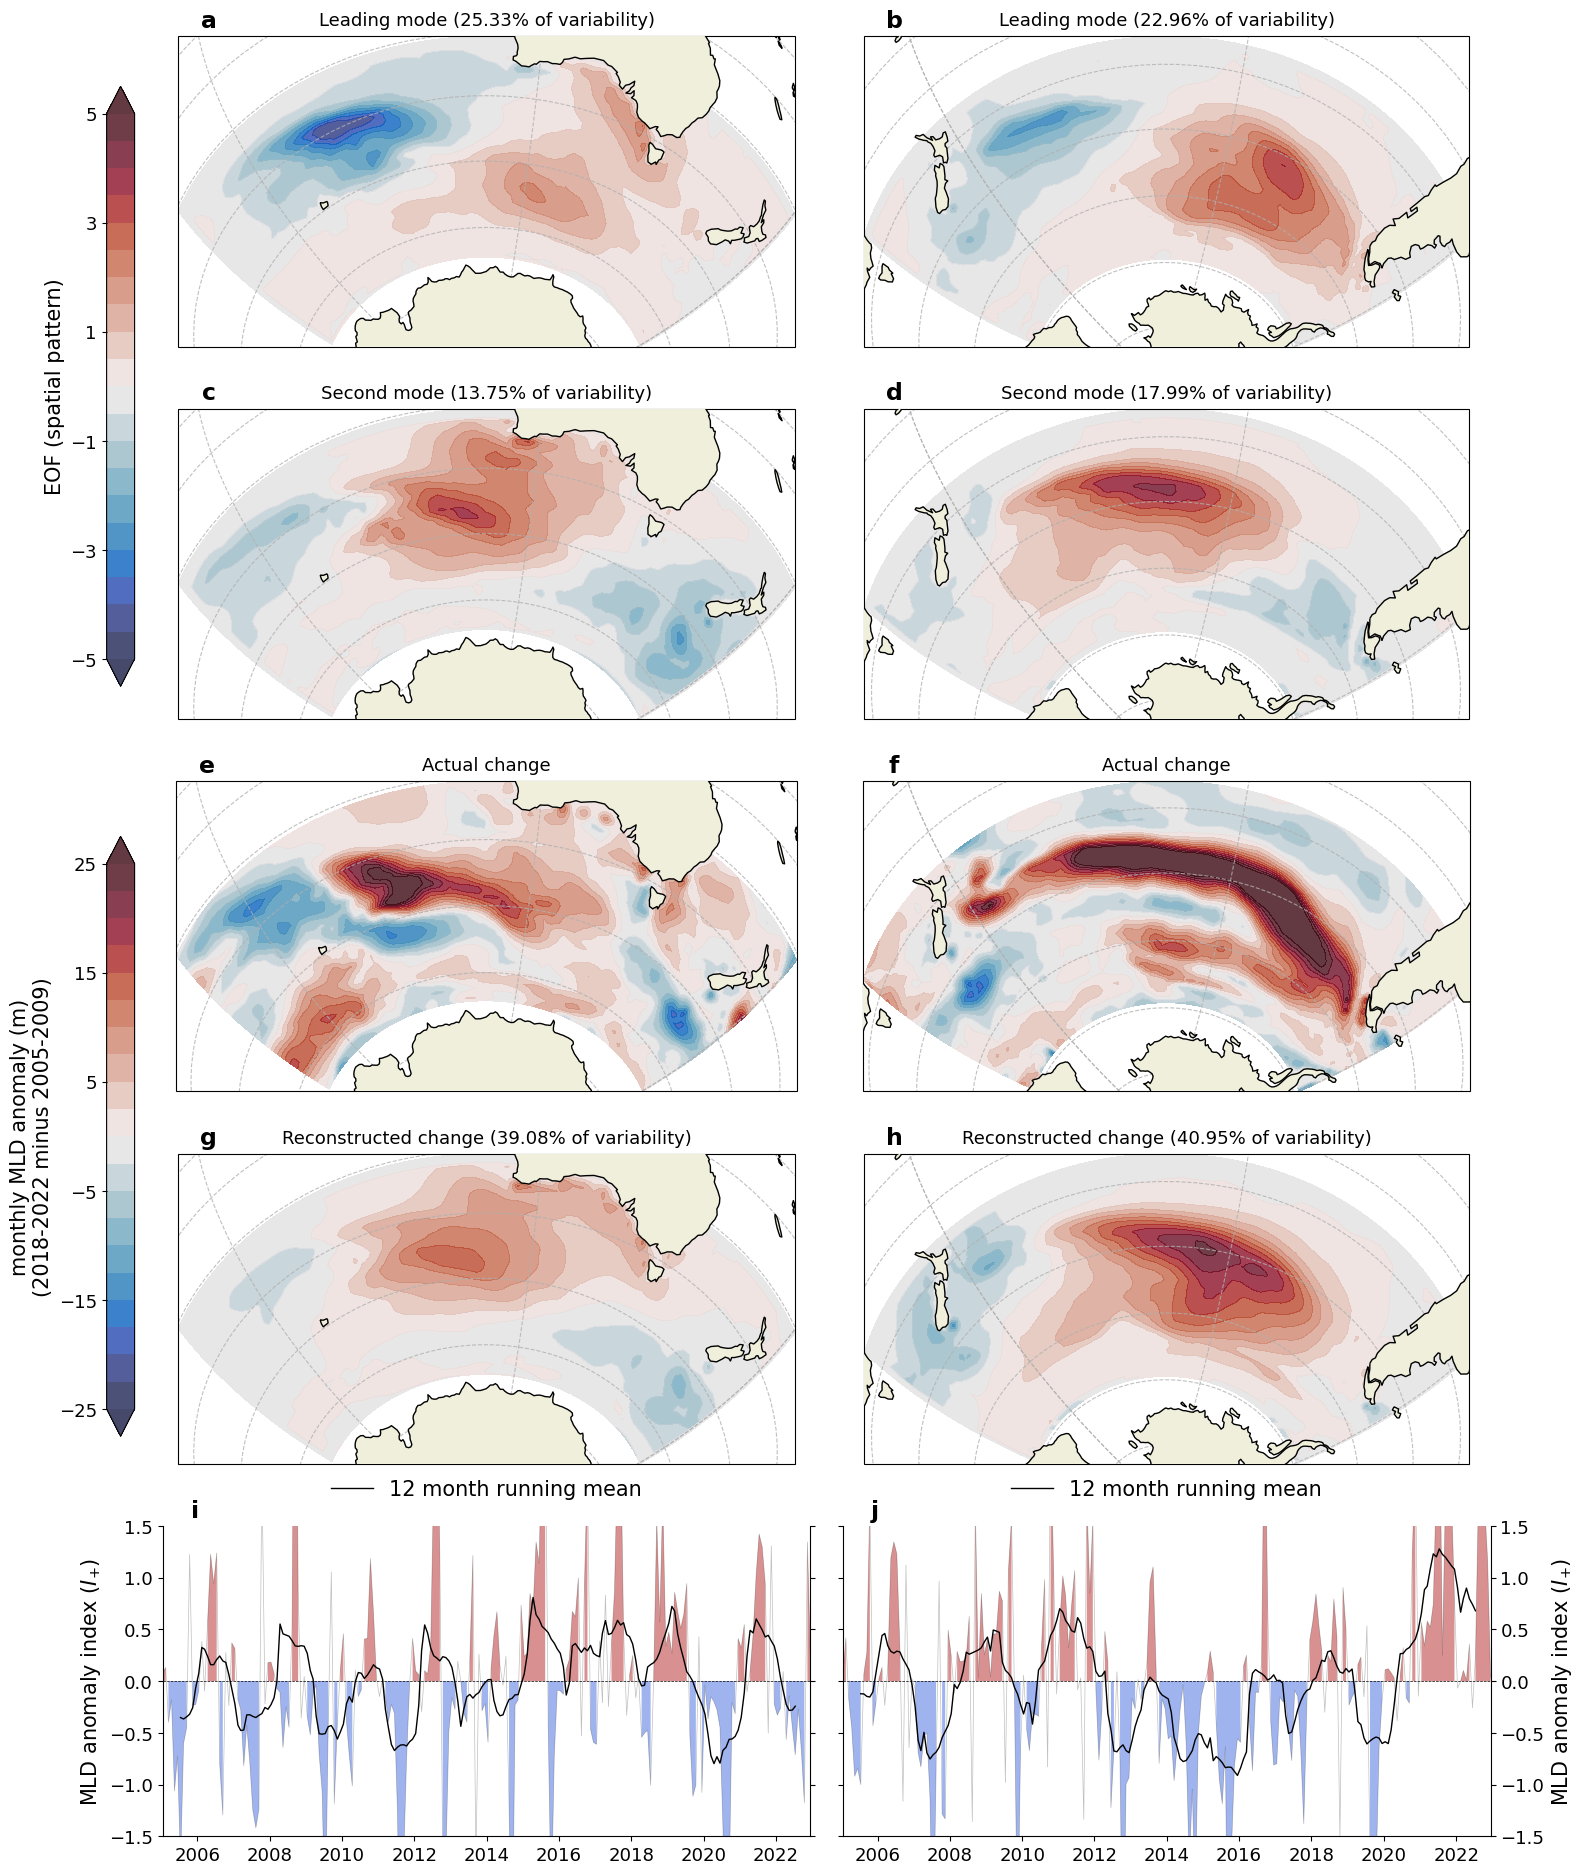

In [103]:
#%% Figure 1 

sind_proj = ccrs.Orthographic(central_latitude=-55, central_longitude=110)
spac_proj = ccrs.Orthographic(central_latitude=-60, central_longitude=225)

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']

levs1 = np.arange(-5,5.1,0.5)
levs2 = np.arange(-25,26,2.5)
colmap = lighten(cmo.balance, 0.8)
fstic = 13
fslab = 15
wid = 1.0

fig = plt.figure(figsize=(16,20), facecolor='w')
gs = GridSpec(5,2)

ax1 = plt.subplot(gs[0,0], projection=sind_proj)
ax2 = plt.subplot(gs[0,1], projection=spac_proj)
ax3 = plt.subplot(gs[1,0], projection=sind_proj)
ax4 = plt.subplot(gs[1,1], projection=spac_proj)
ax5 = plt.subplot(gs[2,0], projection=sind_proj)
ax6 = plt.subplot(gs[2,1], projection=spac_proj)
ax7 = plt.subplot(gs[3,0], projection=sind_proj)
ax8 = plt.subplot(gs[3,1], projection=spac_proj)
ax9 = plt.subplot(gs[4,0])
ax10 = plt.subplot(gs[4,1])

ax1.add_feature(cfeature.LAND, zorder=3)
ax1.add_feature(cfeature.COASTLINE, zorder=3)
ax2.add_feature(cfeature.LAND, zorder=3)
ax2.add_feature(cfeature.COASTLINE, zorder=3)
ax3.add_feature(cfeature.LAND, zorder=3)
ax3.add_feature(cfeature.COASTLINE, zorder=3)
ax4.add_feature(cfeature.LAND, zorder=3)
ax4.add_feature(cfeature.COASTLINE, zorder=3)
ax5.add_feature(cfeature.LAND, zorder=3)
ax5.add_feature(cfeature.COASTLINE, zorder=3)
ax6.add_feature(cfeature.LAND, zorder=3)
ax6.add_feature(cfeature.COASTLINE, zorder=3)
ax7.add_feature(cfeature.LAND, zorder=3)
ax7.add_feature(cfeature.COASTLINE, zorder=3)
ax8.add_feature(cfeature.LAND, zorder=3)
ax8.add_feature(cfeature.COASTLINE, zorder=3)


ax9.tick_params(labelsize=fstic, right=True)
ax10.tick_params(labelsize=fstic, labelleft=False, right=True, labelright=True)
ax9.spines['top'].set_visible(False)
ax10.spines['top'].set_visible(False)

p1 = ax1.contourf(indlons,indlats, U_ind_reg.sel(mode=0), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p2 = ax2.contourf(paclons,paclats, U_pac_reg.sel(mode=0)*(-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_ind.sel(mode=0).values*100), transform=ax1.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Leading mode (%.2f%% of variability)'%(VE_pac.sel(mode=0).values*100), transform=ax2.transAxes, va='center', ha='center', fontsize=fstic)

imodes = 1 
p3 = ax3.contourf(indlons,indlats, U_ind_reg.sel(mode=imodes), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
p4 = ax4.contourf(paclons,paclats, U_pac_reg.sel(mode=imodes)*(-1), transform=ccrs.PlateCarree(), cmap=colmap, levels=levs1, extend='both')
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_ind.sel(mode=imodes).values*100), transform=ax3.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Second mode (%.2f%% of variability)'%(VE_pac.sel(mode=imodes).values*100), transform=ax4.transAxes, va='center', ha='center', fontsize=fstic)

paclons = spac_mld_reg_anom.coords['x']
paclats = spac_mld_reg_anom.coords['y']
indlons = sind_mld_reg_anom.coords['x']
indlats = sind_mld_reg_anom.coords['y']

p5 = ax5.contourf(indlons,indlats, sind_mld_reg_anom.isel(time=slice(-60,-1)).mean(dim='time') - sind_mld_reg_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p6 = ax6.contourf(paclons,paclats, spac_mld_reg_anom.isel(time=slice(-60,-1)).mean(dim='time') - spac_mld_reg_anom.isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')

paclons = U_pac_reg.coords['lon']
paclats = U_pac_reg.coords['lat']
indlons = U_ind_reg.coords['lon']
indlats = U_ind_reg.coords['lat']

p7 = ax7.contourf(indlons,indlats, X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_ind_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')
p8 = ax8.contourf(paclons,paclats, X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(-60,-1)).mean(dim="time") - \
                  X_pac_reconstructed.sel(mode=slice(0,imodes)).sum(dim='mode').isel(time=slice(0,60)).mean(dim="time"), \
                  transform=ccrs.PlateCarree(), cmap=colmap, levels=levs2, extend='both')


ax9.plot(I_ind_pos.coords['time'], I_ind_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax9.plot(I_ind_pos.coords['time'], I_ind_pos.rolling(time=120, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")
ax10.plot(I_pac_pos.coords['time'], I_pac_pos, color='k', linewidth=0.5, linestyle='-', alpha=0.25)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos*0, color='k', linewidth=0.5, linestyle='--', alpha=1.0)
ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=12, center=True).mean(), color='k', linewidth=1.0, linestyle='-', label="12 month running mean")
#ax10.plot(I_pac_pos.coords['time'], I_pac_pos.rolling(time=120, center=True).mean(), color='k', linewidth=2.0, linestyle='-', label="10 year running mean")

ax9.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))
ax10.legend(loc='upper center', frameon=False, fontsize=fslab, bbox_to_anchor=(0.5,1.21))

ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax9.fill_between(I_ind_pos.coords['time'], I_ind_pos.where(I_ind_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos > 0.0, other=np.nan), alpha=0.5, facecolor='firebrick')
ax10.fill_between(I_pac_pos.coords['time'], I_pac_pos.where(I_pac_pos < 0.0, other=np.nan), alpha=0.5, facecolor='royalblue')

#ax9.axvspan(I_ind_pos.coords['time'].sel(time="1987-01-01",method='nearest').values, \
#            I_ind_pos.coords['time'].sel(time="1988-12-31",method='nearest').values, color='goldenrod', alpha=0.25)
#ax10.axvspan(I_pac_pos.coords['time'].sel(time="1996-01-01",method='nearest').values, \
#             I_pac_pos.coords['time'].sel(time="1997-12-31",method='nearest').values, color='goldenrod', alpha=0.25)

ax9.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax10.set_xlim(I_pac_pos.coords['time'].min(), I_pac_pos.coords['time'].max())
ax9.set_ylabel("MLD anomaly index ($I_{+}$)", fontsize=fslab)
ax10.set_ylabel("MLD anomaly index ($I_{+}$)", fontsize=fslab)
ax10.yaxis.set_label_position('right')

ax9.set_ylim(-1.5,1.5)
ax10.set_ylim(-1.5,1.5)

cbax1 = fig.add_axes([0.085,0.625,0.0175,0.30])
cbax5 = fig.add_axes([0.085,0.25,0.0175,0.30])

cbar1 = plt.colorbar(p1, cax=cbax1, orientation='vertical', ticks=levs1[::4])
cbar1.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar1.ax.set_ylabel('EOF (spatial pattern)', fontsize=fslab)
cbar1.ax.yaxis.set_label_position('left')

cbar5 = plt.colorbar(p5, cax=cbax5, orientation='vertical', ticks=levs2[::4])
cbar5.ax.tick_params(labelsize=fstic, right=False, labelright=False, left=True, labelleft=True)
cbar5.ax.set_ylabel('monthly MLD anomaly (m)\n(2018-2022 minus 2005-2009)', fontsize=fslab)
cbar5.ax.yaxis.set_label_position('left')

plt.text(0.5,1.05,'Actual change', transform=ax5.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Actual change', transform=ax6.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_ind.cumsum().sel(mode=imodes).values*100), transform=ax7.transAxes, va='center', ha='center', fontsize=fstic)
plt.text(0.5,1.05,'Reconstructed change (%.2f%% of variability)'%(VE_pac.cumsum().sel(mode=imodes).values*100), transform=ax8.transAxes, va='center', ha='center', fontsize=fstic)

plt.subplots_adjust(left=0.12, top=0.95, right=0.95, bottom=0.05, wspace=0.05)

xx = 0.05; yy = 1.05
plt.text(xx,yy,'a', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax1.transAxes)
plt.text(xx,yy,'b', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax2.transAxes)
plt.text(xx,yy,'c', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax3.transAxes)
plt.text(xx,yy,'d', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax4.transAxes)
plt.text(xx,yy,'e', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax5.transAxes)
plt.text(xx,yy,'f', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax6.transAxes)
plt.text(xx,yy,'g', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax7.transAxes)
plt.text(xx,yy,'h', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax8.transAxes)
plt.text(xx,yy,'i', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax9.transAxes)
plt.text(xx,yy,'j', fontweight='bold', fontsize=fslab+2, va='center', ha='center', transform=ax10.transAxes)

ax1.gridlines(linestyle='--', alpha=0.8)
ax2.gridlines(linestyle='--', alpha=0.8)
ax3.gridlines(linestyle='--', alpha=0.8)
ax4.gridlines(linestyle='--', alpha=0.8)
ax5.gridlines(linestyle='--', alpha=0.8)
ax6.gridlines(linestyle='--', alpha=0.8)
ax7.gridlines(linestyle='--', alpha=0.8)
ax8.gridlines(linestyle='--', alpha=0.8)


In [104]:

fig.savefig('/home/pbuchanan/analysis_samw/fig-mld_trend_reconstructed_2005-2022.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-mld_trend_reconstructed_2005-2022.pdf', dpi=300, bbox_inches='tight')
fig.savefig('/home/pbuchanan/analysis_samw/fig-mld_trend_reconstructed_2005-2022_trans.png', dpi=300, bbox_inches='tight', transparent=True)

### Also save the I+ MLD index
I_ind_pos.to_netcdf('/home/pbuchanan/analysis_samw/Ipos_ind_2005-2022.nc')
I_pac_pos.to_netcdf('/home/pbuchanan/analysis_samw/Ipos_pac_2005-2022.nc')
